# Variance
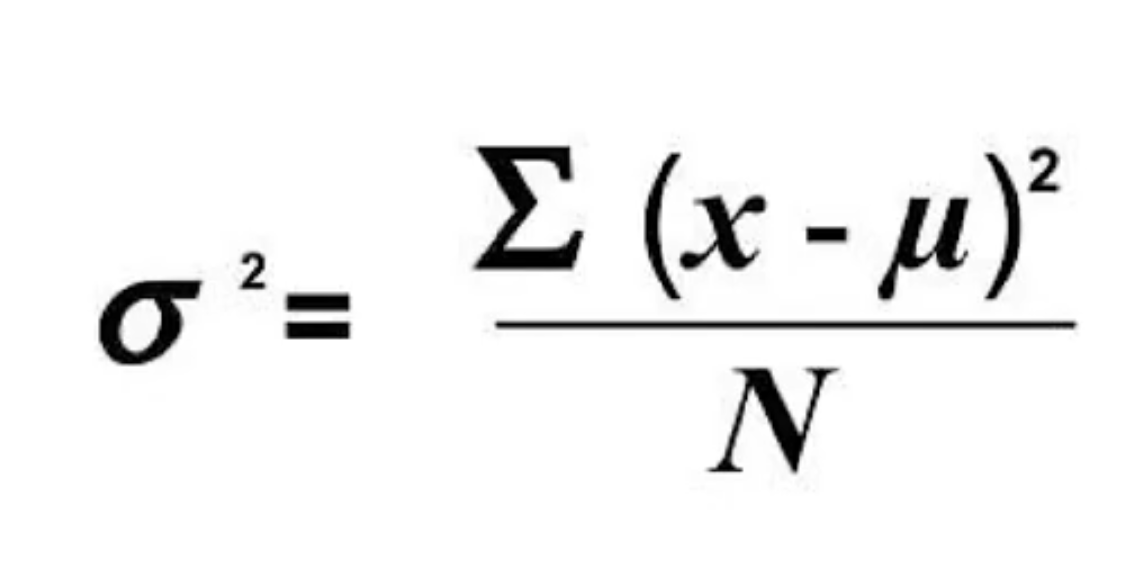
* it tells- on  average how much the sample data deviates from mean value (Average)
* Limitation is units.Units of Variance os Sample units.


- **Definition:** `variance` is the mean squared deviation: $E[(X-\mu)^2]$.  
- **Avoid cancellation:** Squaring makes negative and positive deviations positive, so they don't cancel out.  
- **Emphasize large errors:** Squaring weights larger deviations more, highlighting outliers.  
- **Mathematical convenience:** Squared error is differentiable and leads to closed-form solutions (least squares) and nice algebraic properties.  
- **Additivity:** For independent variables, variances add (useful in probability); raw deviations do not.  
- **Units:** `variance` has squared units; take the square root to get `standard deviation` (original units).

- **What it is:** Bessel’s correction means dividing by `n-1` instead of `n` when computing sample variance:
  - sample variance = `s² = (1/(n-1)) * Σ(xᵢ - x̄)²`
- **Why we use it:** because `x̄` is itself estimated from the same sample, so the raw squared deviations underestimate the true population variance.
- **Intuition:** one degree of freedom is lost by using the sample mean, so only `n-1` independent deviations remain.

### Why `n-1` instead of `n`
- If you use `1/n`, the expected value of that sample variance is smaller than the true variance; it is biased downward.
- With `1/(n-1)`, the sample variance becomes an unbiased estimator of the population variance.


- **“One degree of freedom lost” means:** when you compute the sample mean `x̄`, the deviations `xᵢ - x̄` are not all free to vary independently.
- **Why:** once `n-1` deviations are chosen, the last one is forced so that the sum of deviations equals zero:
  - `Σ(xᵢ - x̄) = 0`
- **Effect on variance:** because the sample mean is estimated from the same data, the squared deviations around `x̄` are systematically smaller than squared deviations around the true mean `μ`.
- **Result:** there are only `n-1` independent pieces of information left for estimating variance, not `n`.
- **Consequences:** dividing by `n` makes the sample variance too small on average; dividing by `n-1` corrects that bias and gives an unbiased estimate of the population variance.



### Short proof outline
1. Let population mean be `μ` and sample mean `x̄`.
2. Decompose total squared deviation:
   - `Σ(xᵢ - μ)² = Σ(xᵢ - x̄)² + n(x̄ - μ)²`
3. Take expectation over random samples:
   - `E[Σ(xᵢ - μ)²] = n σ²`
   - `E[n(x̄ - μ)²] = σ²`
4. Then:
   - `E[Σ(xᵢ - x̄)²] = nσ² - σ² = (n-1)σ²`
5. Therefore:
   - `E[(1/(n-1)) Σ(xᵢ - x̄)²] = σ²`
   - but `E[(1/n) Σ(xᵢ - x̄)²] = ((n-1)/n) σ² < σ²`

### Bottom line
- Bessel’s correction makes sample variance unbiased.
- It corrects for the fact that the sample mean is not the true mean and removes one degree of freedom.

# Standard Deviation 
* Square root of Variance 
* It tells - On average how much the sample data deviates from mean Value(Average)
* Units of Standard deviation is same as of Sample Units.

In [11]:
import numpy as np
import time 


In [12]:
np.random.seed(42)
data = np.random.randint(1,101,size=1000000) # random integers 1-1000

In [13]:
# -------------------------------------------
# Scratch Implementation of Variance and Standard Deviation
# -------------------------------------------
def mean_from_scratch(data):
    return sum(data)/len(data)


def variance_from_scratch(data):
    n =len(data)
    mean = mean_from_scratch(data)
    return sum((x-mean)**2 for x in data)/(n-1) # sample variance

def std_deviation_from_scratch(data):
    return variance_from_scratch(data)**0.5

In [14]:
# ----------------------------
# measure execution time for scratch implementation
#--------------------------------------------
start=time.time()
variance_scratch = variance_from_scratch(data)
std_scratch = std_deviation_from_scratch(data)
time_scratch = time.time()-start

In [15]:
# --------------------------------------------
# Built-in Implementation of Variance and Standard Deviation
# --------------------------------------------
start=time.time()
mean_np = np.mean(data)
variance_np = np.var(data, ddof=1) # sample variance ,ddof =delta degrees of freedom
std_np = np.std(data, ddof=1) # sample standard deviation
time_np = time.time()-start

In [16]:
# --------------------------------------------
# Result Comparison
# --------------------------------------------
print("Scratch Implementation:")
print(f"Variance: {variance_scratch:.2f}")
print(f"Standard Deviation: {std_scratch:.2f}")
print(f"Execution Time: {time_scratch:.6f} seconds\n")  
print("Built-in Implementation:")
print(f"Variance: {variance_np:.2f}")
print(f"Standard Deviation: {std_np:.2f}")
print(f"Execution Time: {time_np:.6f} seconds\n")  
print("\nspeed -up Factor:{:.2f}x faster with Numpy".format(time_scratch/time_np))


Scratch Implementation:
Variance: 834.44
Standard Deviation: 28.89
Execution Time: 0.784283 seconds

Built-in Implementation:
Variance: 834.44
Standard Deviation: 28.89
Execution Time: 0.015998 seconds


speed -up Factor:49.02x faster with Numpy
